In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split #,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
# from sklearn.ensemble import RandomForestClassifier


import matplotlib.pyplot as plt
import seaborn as sns
import  warnings
warnings.filterwarnings('ignore')

### Data Gathering

In [2]:

df =  pd.read_csv(r"C:\Velocity\Practice\5.Git_GitHub\Teen_Mental_Health\data\Teen_Mental_Health_Dataset.csv")
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


### EDA and Preprocessing


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [4]:
df.value_counts('depression_label')

depression_label
0    1169
1      31
Name: count, dtype: int64

### Train_Test_Split

In [5]:
x = df.drop(labels="depression_label",axis=1)
y = df['depression_label']

x_train,x_test,y_train,y_test = train_test_split(x,y , test_size=0.25,random_state=20,stratify=y)

In [6]:
print(y_train.value_counts())
y_test.value_counts()

depression_label
0    877
1     23
Name: count, dtype: int64


depression_label
0    292
1      8
Name: count, dtype: int64

### Outliers Checking

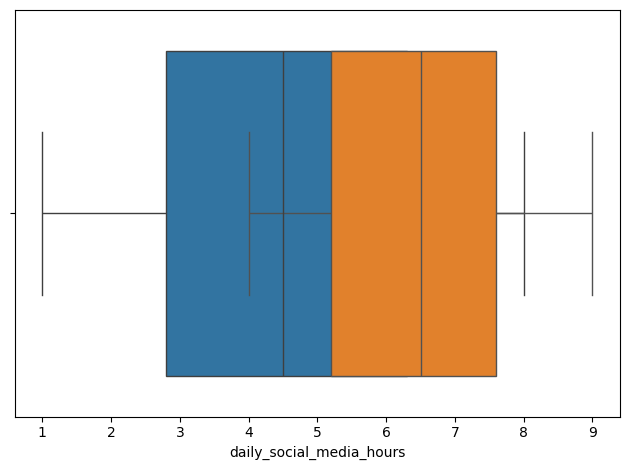

Outlier counts based on IQR method (1.5 * IQR):
daily_social_media_hours: 0 outliers
sleep_hours: 0 outliers


In [7]:
cols_to_check = ['daily_social_media_hours','sleep_hours']

# --- VISUAL CHECK: Boxplots ---
for i,cols in enumerate(cols_to_check):
    sns.boxplot(x = df[cols])

plt.tight_layout()
plt.show()

# --- MATHEMATICAL CHECK: IQR Method ---
print("Outlier counts based on IQR method (1.5 * IQR):")
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many rows fall outside the bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

#### Label + Ordinal Encoding

In [8]:
x_train['gender'] = x_train['gender'].replace({'male': 0, "female": 1})
x_train['social_interaction_level'] = x_train['social_interaction_level'].replace({'low': 1, 'medium': 2, "high": 3})

x_train = pd.get_dummies(x_train,columns=['platform_usage'],dtype=int)

In [9]:
x_test['gender'] = x_test['gender'].replace({'male': 0, "female": 1})
x_test['social_interaction_level'] = x_test['social_interaction_level'].replace({'low': 1, 'medium': 2, "high": 3})

x_test = pd.get_dummies(x_test,columns=['platform_usage'],dtype=int)

### Feature Scaling

In [10]:
std_scaler = StandardScaler()

x_train_scaled = pd.DataFrame(std_scaler.fit_transform(x_train), columns=x_train.columns)
x_test_scaled = pd.DataFrame(std_scaler.transform(x_test), columns=x_test.columns)

In [11]:
# #Model Training
# rnd_clf = RandomForestClassifier(class_weight='balanced',random_state=42)
# param = {
#             'n_estimators': [50, 100, 200],      
#             'max_depth': [None, 10, 20],         
#             'min_samples_split': [2, 5],         
#             'min_samples_leaf': [1, 2]
#              }

# gdscv_model = GridSearchCV(estimator=rnd_clf,param_grid= param,n_jobs=-1,verbose=1,cv= 5)
# gdscv_model.fit(x_train,y_train)

In [12]:
# rdf_clf = gdscv_model.best_estimator_
# rdf_clf.fit(x_train,y_train)

### Model Training

In [13]:
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### Training Model Evalution 

In [14]:
y_pred_train = log_reg.predict(x_train_scaled)

print("--- Training Data Evaluation ---")
print(confusion_matrix(y_train, y_pred_train))
print("\nAccuracy Score:", accuracy_score(y_train, y_pred_train))
print("\n", classification_report(y_train, y_pred_train))

--- Training Data Evaluation ---
[[825  52]
 [  0  23]]

Accuracy Score: 0.9422222222222222

               precision    recall  f1-score   support

           0       1.00      0.94      0.97       877
           1       0.31      1.00      0.47        23

    accuracy                           0.94       900
   macro avg       0.65      0.97      0.72       900
weighted avg       0.98      0.94      0.96       900



### Training Model Evalution 

In [15]:
y_pred_test = log_reg.predict(x_test_scaled)

print("\n--- Testing Data Evaluation ---")
print(confusion_matrix(y_test, y_pred_test))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_test))
print("\n", classification_report(y_test, y_pred_test))


--- Testing Data Evaluation ---
[[275  17]
 [  0   8]]

Accuracy Score: 0.9433333333333334

               precision    recall  f1-score   support

           0       1.00      0.94      0.97       292
           1       0.32      1.00      0.48         8

    accuracy                           0.94       300
   macro avg       0.66      0.97      0.73       300
weighted avg       0.98      0.94      0.96       300



### Save the Model

In [16]:
import pickle  as pkl
import os,json

In [17]:
df['gender'] = df['gender'].replace({'male': 0, "female": 1},inplace = True)
df['social_interaction_level'] = df['social_interaction_level'].replace({'low': 1, 'medium': 2, "high": 3},inplace = True)
df = pd.get_dummies(df,columns=['platform_usage'],dtype=int)
df

,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok
0,14,0,7.9,7.4,2.9,3.01,1.5,1,2,2,1,0,0,1,0
1,19,1,1.9,8.0,2.9,3.22,0.8,3,8,1,10,0,0,0,1
2,17,1,1.3,7.6,0.5,3.92,0.0,3,2,4,2,0,0,1,0
3,15,0,7.4,6.9,1.6,3.48,0.8,2,1,7,9,0,0,0,1
4,15,1,4.7,4.9,3.0,2.37,1.4,2,3,5,2,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,1,6.8,6.6,2.0,2.76,1.0,1,3,4,4,0,0,1,0
1196,16,0,2.3,8.0,1.9,2.12,0.4,3,7,4,4,0,1,0,0
1197,14,1,1.7,8.7,0.7,3.98,0.8,3,1,1,1,0,1,0,0
1198,15,0,3.9,8.5,2.1,3.19,0.6,3,7,9,9,0,1,0,0


In [18]:
#Saving column options
std_depr_json = { "gender":{'male': 0, "female": 1},
                 "social_interaction_level": {'low': 1, 'medium': 2, "high": 3},
                 'colName':list(log_reg.feature_names_in_)
               }
std_depr_json

{'gender': {'male': 0, 'female': 1},
 'social_interaction_level': {'low': 1, 'medium': 2, 'high': 3},
 'colName': ['age',
  'gender',
  'daily_social_media_hours',
  'sleep_hours',
  'screen_time_before_sleep',
  'academic_performance',
  'physical_activity',
  'social_interaction_level',
  'stress_level',
  'anxiety_level',
  'addiction_level',
  'platform_usage_Both',
  'platform_usage_Instagram',
  'platform_usage_TikTok']}

In [19]:
with open("Teen_depr_coln_data.json",'w') as j:
    json.dump(std_depr_json,j)

In [20]:
#Saving the Model
with open("Teen_Depr_final_model.pkl",'wb') as f:
    pkl.dump(log_reg,f)

#Saving standard_scaler
with open('std_scaler.pkl',"wb") as s:
    pkl.dump(std_scaler,s)